# Mumbai Property Sales — Predictive Analytics
## Group Coursework
### City: Mumbai, India (Emerging Economy)¶


In [134]:
#Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [135]:
df=pd.read_csv('mumbai.csv')

# Section 1- Understanding The Data

In [136]:
df.head()

,id,date_listed,locality,region,tier,lat,lon,property_type,bedrooms,carpet_area_sqft,...,metro_station,metro_line,metro_distance_min,metro_distance_type,to_bkc_km,to_nariman_point_km,price_inr,price_per_sqft_carpet_inr,price_usd,home_loan_rate_at_listing
0,S000001,2024-11-23,Breach Candy,South Mumbai,luxury,18.96953,72.81853,3BHK,3,1048,...,Grant Road Metro,Line 3,19,walk,12.41,4.82,61694000,58893,740322,9.20
1,S000002,2023-07-05,Breach Candy,South Mumbai,luxury,18.97230,72.81017,2BHK,2,729,...,BKC Metro,Line 3,56,auto/bus,12.55,5.29,40127000,55039,481523,9.20
2,S000003,2022-01-22,Malad East,Western,mid,19.18986,72.85940,2BHK,2,705,...,Dahanukarwadi,Line 2A,19,walk,13.37,29.52,10450000,14813,125398,7.10
3,S000004,2020-11-18,Mulund West,Central,mid,19.15854,72.93798,1BHK,1,424,...,Siddhivinayak,Line 3,90,auto/bus,12.16,28.46,5420000,12781,65036,6.70
4,S000005,2025-01-11,Matunga,Central,premium,19.02358,72.85690,1BHK,1,392,...,Bandra WR,Western Rail,18,auto/bus,5.34,11.35,11713000,29860,140553,8.95


In [137]:
df.shape

(50000, 32)

In [138]:
df.describe()

,lat,lon,bedrooms,carpet_area_sqft,built_up_area_sqft,carpet_area_m2,floor,total_floors,year_built,balconies,metro_distance_min,to_bkc_km,to_nariman_point_km,price_inr,price_per_sqft_carpet_inr,price_usd,home_loan_rate_at_listing
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,5.000000e+04,50000.000000
mean,19.107127,72.901199,2.510840,896.69346,1120.909980,83.305358,10.301920,19.696600,2012.715640,1.401160,32.463260,14.438034,23.564604,2.312204e+07,24006.515900,2.774645e+05,8.158140
std,0.115304,0.097404,1.102391,528.63484,661.314004,49.111622,8.513047,11.073942,9.809472,0.799502,36.498673,9.405541,13.553553,2.836063e+07,19745.976546,3.403275e+05,1.061495
min,18.885770,72.751060,1.000000,280.00000,336.000000,26.000000,1.000000,7.000000,1985.000000,0.000000,2.000000,0.030000,0.010000,5.510000e+05,1367.000000,6.611000e+03,6.700000
25%,19.017547,72.832180,2.000000,570.00000,711.000000,53.000000,4.000000,12.000000,2007.000000,1.000000,9.000000,7.250000,12.587500,6.062000e+06,8698.000000,7.274600e+04,6.700000
50%,19.093600,72.857260,2.000000,734.00000,919.000000,68.200000,8.000000,20.000000,2016.000000,1.000000,19.000000,13.250000,23.420000,1.281850e+07,16989.500000,1.538235e+05,8.700000
75%,19.182423,72.966252,3.000000,1039.00000,1298.000000,96.500000,14.000000,30.000000,2020.000000,2.000000,43.000000,18.920000,32.000000,2.810525e+07,33947.500000,3.372632e+05,9.200000
max,19.482950,73.270670,5.000000,4031.00000,5183.000000,374.500000,45.000000,45.000000,2024.000000,3.000000,242.000000,46.300000,61.880000,3.370250e+08,112384.000000,4.044296e+06,9.200000


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         50000 non-null  object 
 1   date_listed                50000 non-null  object 
 2   locality                   50000 non-null  object 
 3   region                     50000 non-null  object 
 4   tier                       50000 non-null  object 
 5   lat                        50000 non-null  float64
 6   lon                        50000 non-null  float64
 7   property_type              50000 non-null  object 
 8   bedrooms                   50000 non-null  int64  
 9   carpet_area_sqft           50000 non-null  int64  
 10  built_up_area_sqft         50000 non-null  int64  
 11  carpet_area_m2             50000 non-null  float64
 12  floor                      50000 non-null  int64  
 13  total_floors               50000 non-null  int

In [140]:
# 1. Parse dates
df['date_listed'] = pd.to_datetime(df['date_listed'])
df['listing_year'] = df['date_listed'].dt.year
df['listing_month'] = df['date_listed'].dt.month

In [141]:
print(df[['floor','total_floors','year_built','bedrooms']].describe())
print("Rows where floor > total_floors:", (df['floor'] > df['total_floors']).sum())

              floor  total_floors    year_built      bedrooms
count  50000.000000  50000.000000  50000.000000  50000.000000
mean      10.301920     19.696600   2012.715640      2.510840
std        8.513047     11.073942      9.809472      1.102391
min        1.000000      7.000000   1985.000000      1.000000
25%        4.000000     12.000000   2007.000000      2.000000
50%        8.000000     20.000000   2016.000000      2.000000
75%       14.000000     30.000000   2020.000000      3.000000
max       45.000000     45.000000   2024.000000      5.000000
Rows where floor > total_floors: 0


# Data Preparation

In [142]:
#Drop leakage columns — price_per_sqft is derived from price_inr
df = df.drop(columns=['price_per_sqft_carpet_inr', 'price_inr'])

In [143]:
df.isna().sum()

id                           0
date_listed                  0
locality                     0
region                       0
tier                         0
lat                          0
lon                          0
property_type                0
bedrooms                     0
carpet_area_sqft             0
built_up_area_sqft           0
carpet_area_m2               0
floor                        0
total_floors                 0
year_built                   0
facing                       0
furnishing                   0
parking                      0
balconies                    0
is_sra_redevelopment         0
builder                      0
builder_tier                 0
metro_station                0
metro_line                   0
metro_distance_min           0
metro_distance_type          0
to_bkc_km                    0
to_nariman_point_km          0
price_usd                    0
home_loan_rate_at_listing    0
listing_year                 0
listing_month                0
dtype: i

In [144]:
df.duplicated().sum()

np.int64(0)

In [145]:
#Dropping redundant area columns (carpet_area_sqft, built_up_area_sqft,
# carpet_area_m2 all measure the same thing → multicollinearity)
df = df.drop(columns=['carpet_area_m2'])  # keep sqft versions

In [146]:
#Feature engineering
df['property_age'] = df['listing_year'] - df['year_built']
df['bhk_num'] = df['property_type'].str.extract(r'(\d+)').astype(int)

In [147]:
# Check outlier rate by tier — confirms whether "outliers" are just the luxury segment
for tier in df['tier'].unique():
    sub = df[df['tier'] == tier]['price_usd']
    q1, q3 = sub.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = ((sub < lo) | (sub > hi)).sum()
    print(f"{tier}: {outliers} outliers out of {len(sub)} ({outliers/len(sub)*100:.1f}%)")

luxury: 450 outliers out of 9466 (4.8%)
mid: 1080 outliers out of 17901 (6.0%)
premium: 770 outliers out of 11936 (6.5%)
affordable: 704 outliers out of 10697 (6.6%)


In [148]:
before = len(df)
df = df[df['floor'] <= df['total_floors']]
df = df[df['year_built'] <= df['listing_year']]
print(f"Removed {before - len(df)} rows with logical errors")

Removed 4793 rows with logical errors


# Initial Visualization

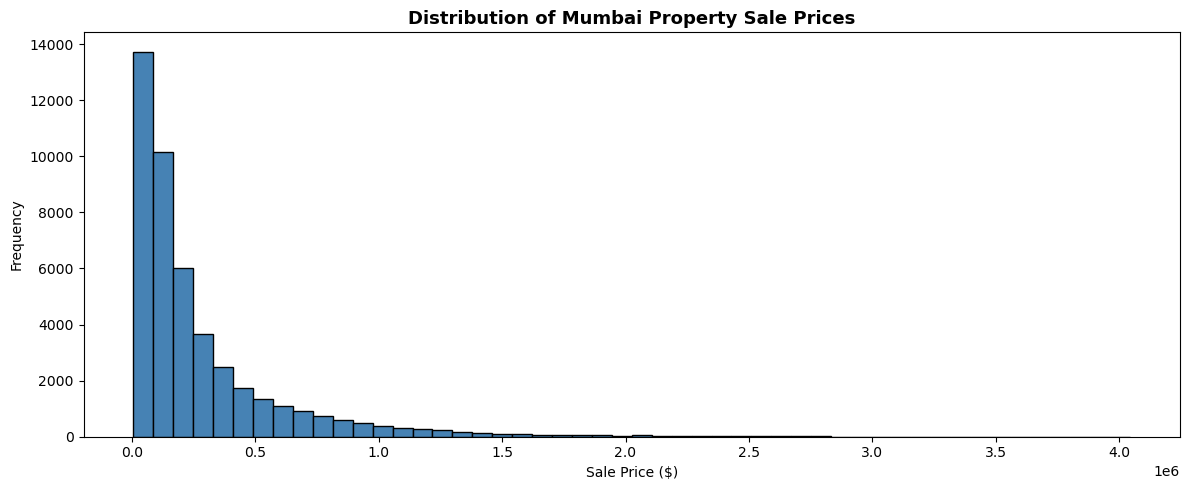

In [149]:
plt.figure(figsize=(12, 5))
plt.hist(df['price_usd'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Mumbai Property Sale Prices', fontsize=13, fontweight='bold')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

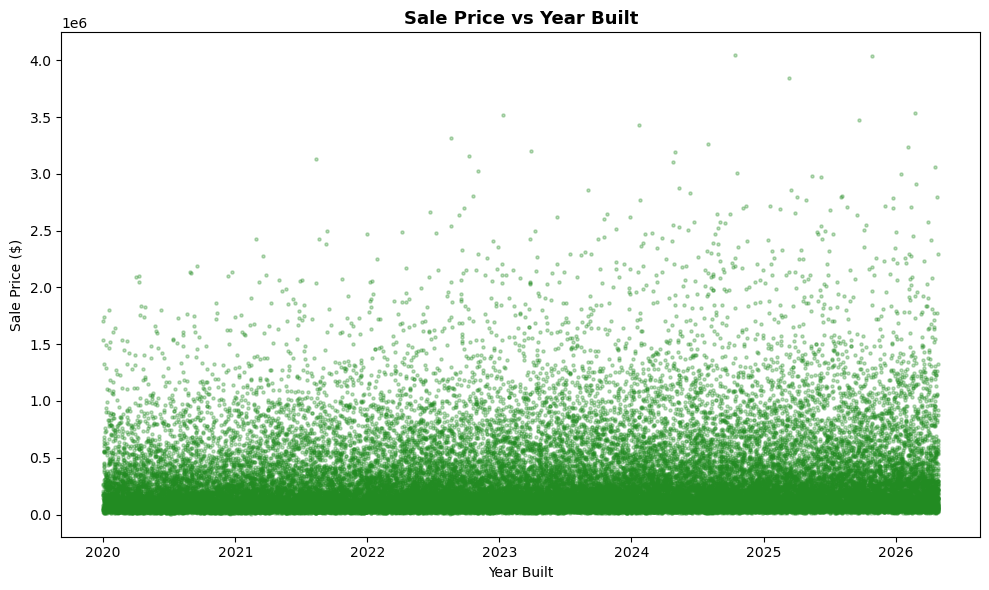

In [150]:
# Visualization 4: Price vs Year Built
# Checking if newer buildings command higher prices

plt.figure(figsize=(10, 6))
plt.scatter(df['date_listed'], df['price_usd'],
            alpha=0.3, color='forestgreen', s=5)
plt.title('Sale Price vs Year Built', fontsize=13, fontweight='bold')
plt.xlabel('Year Built')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

# Splitting The Data

In [151]:
#Define target and features
target = 'price_usd'
drop_cols = ['id', 'date_listed', 'price_usd', 'property_type']  # keep bhk_num instead
x = df.drop(columns=drop_cols)
y = df[target]

In [152]:
#Splitting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Encoding

In [153]:
#encoding categorical values
low_card = ['region', 'tier', 'facing', 'furnishing', 'parking',
            'builder_tier', 'metro_distance_type', 'metro_line', 'is_sra_redevelopment']
high_card = ['locality', 'builder', 'metro_station']

In [154]:
# One-hot for low cardinality
x_train = pd.get_dummies(x_train, columns=low_card, drop_first=True)
x_test = pd.get_dummies(x_test, columns=low_card, drop_first=True)
# align columns in case some categories missing in test
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [155]:
#Mean target encoding for high cardinality
for col in high_card:
    means = y_train.groupby(x_train[col]).mean()
    global_mean = y_train.mean()
    x_train[col + '_enc'] = x_train[col].map(means)
    x_test[col + '_enc'] = x_test[col].map(means).fillna(global_mean)
    x_train = x_train.drop(columns=[col])
    x_test = x_test.drop(columns=[col])

print(x_train.shape, x_test.shape)

(36165, 51) (9042, 51)


In [156]:
from sklearn.linear_model import Lasso,Ridge

In [157]:
# Log-transform target (prices are right-skewed)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Feature Scaling

In [158]:
# Scaling numeric features
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)  

# LINEAR REGRESSION
## Building the Model

In [159]:
model=LinearRegression()

In [160]:
model.fit(x_train_sc,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [161]:
y_pred=model.predict(x_test_sc)
print(y_pred[:10])

[ 97406.02022232  34769.2570853  373762.6434473  -40229.98515831
  43157.48857211 211104.1692211   40762.59404553 101617.15292375
 125222.9388802  307065.90699866]


In [162]:
#Checking model intercept 
model.intercept_

np.float64(280681.9631411579)

In [163]:
#Checking the coefficients
model.coef_

array([ 1.32829192e+04,  1.09800015e+04, -1.87194883e+04,  2.57450661e+05,
       -5.74546087e+04,  1.02334821e+04, -3.87777305e+03,  7.13393961e+03,
       -3.28175773e+02, -1.06759573e+04,  5.81958869e+03, -2.44108208e+04,
        3.43207831e+03,  2.65146438e+04,  3.11012263e+03, -2.15494979e+03,
       -1.87194883e+04,  3.43082987e+03, -3.78362277e+03,  3.60416467e+01,
       -1.50534627e+03,  1.65932487e+02, -1.44979288e+03,  1.97972707e+03,
        1.93039043e+03,  6.89818231e+02,  3.91243937e+03, -3.99279593e+03,
       -6.58403188e+03, -2.98229946e+03, -6.87602014e+03, -5.37538435e+03,
       -6.43003602e+03, -1.24370807e+04, -6.84979674e+02,  1.63898793e+03,
       -2.59336199e+02,  3.44187707e+03,  1.51132218e+03,  1.01803376e+03,
        5.36284417e+02,  2.22173561e+03,  2.86461649e+03,  1.22359035e+03,
        3.22285384e+03,  3.07131162e+02,  5.14785529e+02, -8.48817109e+03,
        2.17753558e+05,  1.82739034e+04,  1.15768839e+04])

In [164]:
#Checking for the difference in the actual and predicted values
residuals=y_test-y_pred
residuals

6372       3579.979778
22849     39968.742915
31456   -254601.643447
35955     85684.985158
12992     31576.511428
             ...      
4153     -23465.735727
49649     80187.235730
3669    -259560.793403
21000    -97069.386930
17592     41994.440085
Name: price_usd, Length: 9042, dtype: float64

In [165]:
results=pd.DataFrame({'Actual':y_test,
                      'Predicted':y_pred})
results

,Actual,Predicted
6372,100986,97406.020222
22849,74738,34769.257085
31456,119161,373762.643447
35955,45455,-40229.985158
12992,74734,43157.488572
...,...,...
4153,227350,250815.735727
49649,49632,-30555.235730
3669,601262,860822.793403
21000,225312,322381.386930


In [166]:
results['Residual']=residuals
results.head()

,Actual,Predicted,Residual
6372,100986,97406.020222,3579.979778
22849,74738,34769.257085,39968.742915
31456,119161,373762.643447,-254601.643447
35955,45455,-40229.985158,85684.985158
12992,74734,43157.488572,31576.511428


In [167]:
r2=r2_score(y_test,y_pred)
r2

0.8259279071199297

In [168]:
mae=mean_absolute_error(y_test,y_pred)
mae

81768.98121546172

# Ridge Regression

In [169]:
#Importing ridge regression
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(x_train_sc, y_train)            #Fitting the data

print("Best alpha:", ridge_cv.alpha_)
y_pred_ridge = ridge_cv.predict(x_test_sc)
r2_score(y_test, y_pred_ridge)

Best alpha: 1.0


0.8259406262687314

# Actual vs Predicted

Text(0.5, 1.0, 'Actual vs Predicted')

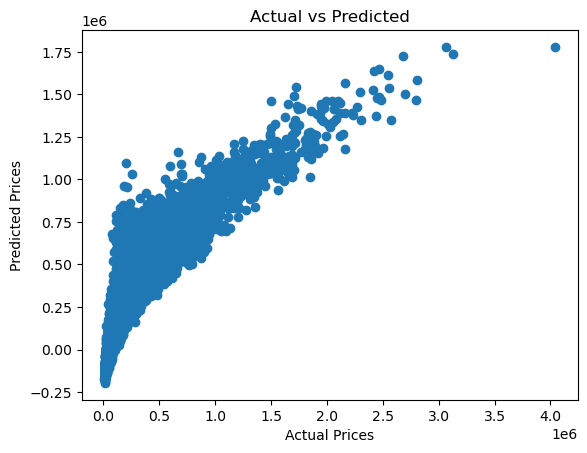

In [170]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted')

# TIME SERIES
## ARIMA

In [171]:
monthly = df.set_index('date_listed').resample('M')['price_usd'].mean().reset_index()
monthly.columns = ['month', 'avg_price']

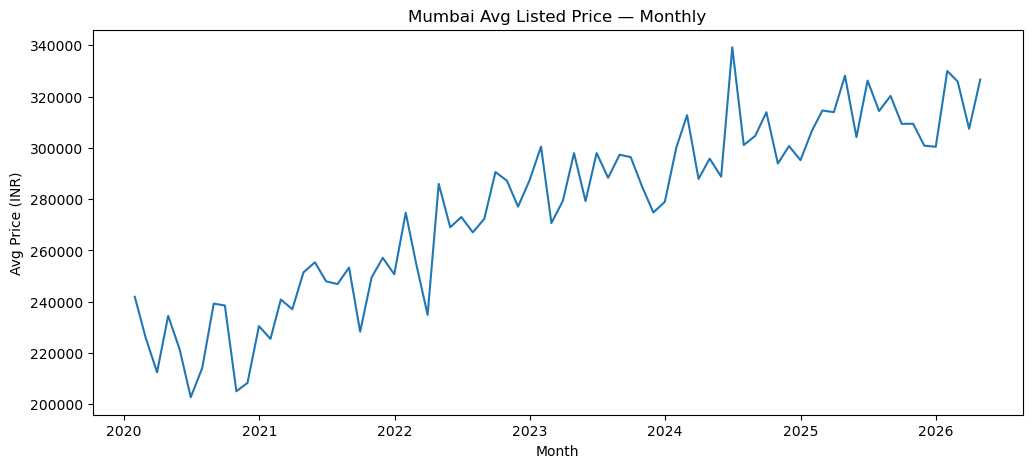

In [172]:
plt.figure(figsize=(12,5))
plt.plot(monthly['month'], monthly['avg_price'])
plt.title('Mumbai Avg Listed Price — Monthly')
plt.xlabel('Month'); plt.ylabel('Avg Price (INR)')
plt.show()


In [173]:
#Ho: It is non stationary
#H1: It is stationary
from statsmodels.tsa.stattools import adfuller
test_result=adfuller(monthly['avg_price'])

In [174]:
def adfuller_test(price):
    result=adfuller(price)
    labels=['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observation Used']
    for value, label in zip(result, labels):
        print(label+':'+str(value))
    if result[1]<=0.05:
        print('strong evidence against the null hypothesis(Ho), reject the null hypothesi. Data has no unit root and is stationary')
    else:
        print('weak evidence against the null hypothesis, time series has a unit root, indicating it is non stationary')
adfuller_test(monthly['avg_price'])

ADF Test Statistic:-2.7038103609345296
p-value:0.07338122794554389
#Lags Used:11
Number of Observation Used:64
weak evidence against the null hypothesis, time series has a unit root, indicating it is non stationary


In [175]:
monthly.head()

,month,avg_price
0,2020-01-31,241899.053950
1,2020-02-29,226168.142259
2,2020-03-31,212498.285141
3,2020-04-30,234505.375000
4,2020-05-31,221429.154297


In [176]:
monthly['Price First Difference']=monthly['avg_price']-monthly['avg_price'].shift(1)

In [177]:
monthly.head()

,month,avg_price,Price First Difference
0,2020-01-31,241899.053950,NaN
1,2020-02-29,226168.142259,-15730.911690
2,2020-03-31,212498.285141,-13669.857119
3,2020-04-30,234505.375000,22007.089859
4,2020-05-31,221429.154297,-13076.220703


In [178]:
def adfuller_test(Price_First_Difference):
    result=adfuller(Price_First_Difference)
    labels=['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observation Used']
    for value, label in zip(result, labels):
        print(label+':'+str(value))
    if result[1]<=0.05:
        print('strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary')
    else:
        print('weak evidence against the null hypothesis, time series has a unit root, indicating it is non stationary')
adfuller_test(monthly['Price First Difference'].dropna())

ADF Test Statistic:-7.360660606604283
p-value:9.519713784660576e-11
#Lags Used:3
Number of Observation Used:71
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


In [179]:
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

In [180]:
clean_data=monthly['Price First Difference'].dropna()
auto_model=auto_arima(clean_data,
                      start_p=0, start_q=0,
                      max_p=5, max_q=5,
                      m=12,
                      seasonal=True,
                      d=None,
                      trace=True,
                      error_action='ignore',
                      duppress_warnings=True,
                      stepwise=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=1676.382, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1680.178, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1667.562, Time=0.04 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1657.931, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1678.499, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=1646.728, Time=0.05 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=1661.233, Time=0.05 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=1660.624, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[12] intercept   : AIC=1684.611, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1668.110, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(0,0,1)(0,0,0)[12]             : AIC=1653.048, Time=0.02 sec

Best model:  ARIMA(0,0,1)(0,0,0)[12] intercept
Total fit time: 0.825 seconds
                  

In [181]:
#Check model performance
print('Model Summary')
print(auto_model.summary())

Model Summary
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   75
Model:               SARIMAX(0, 0, 1)   Log Likelihood                -820.364
Date:                Tue, 04 Aug 2026   AIC                           1646.728
Time:                        16:33:30   BIC                           1653.680
Sample:                             0   HQIC                          1649.504
                                 - 75                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1361.7816    309.450      4.401      0.000     755.271    1968.293
ma.L1         -0.8429      0.086     -9.819      0.000      -1.011      -0.675
sigma2      2.065e+08      0.000   5.5

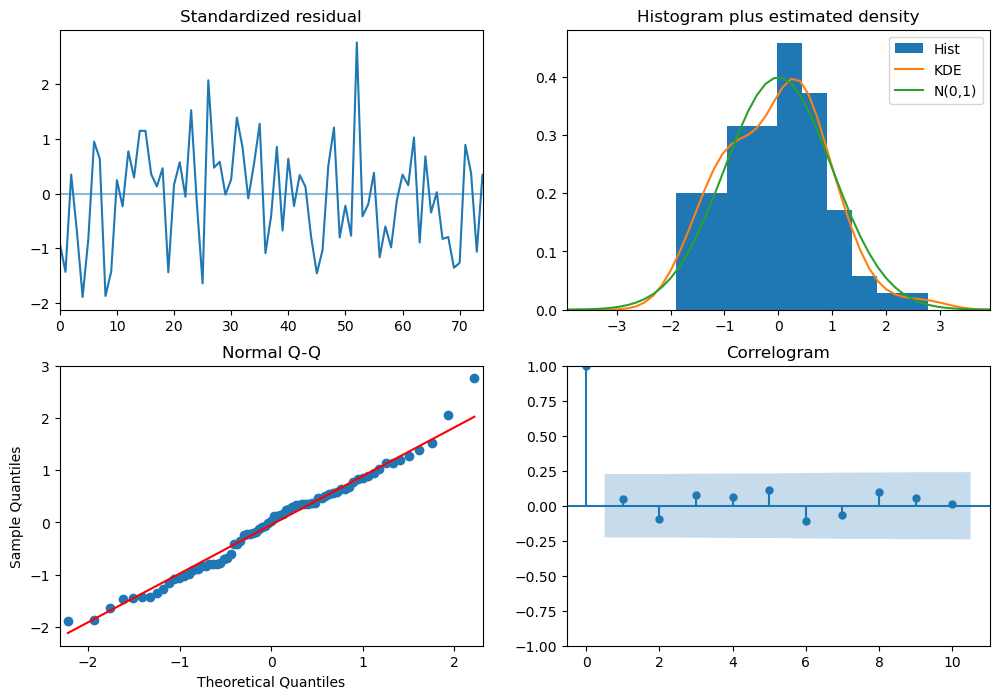

In [182]:
#Plot residuals
auto_model.plot_diagnostics(figsize=(12,8))
plt.show()

## SMA

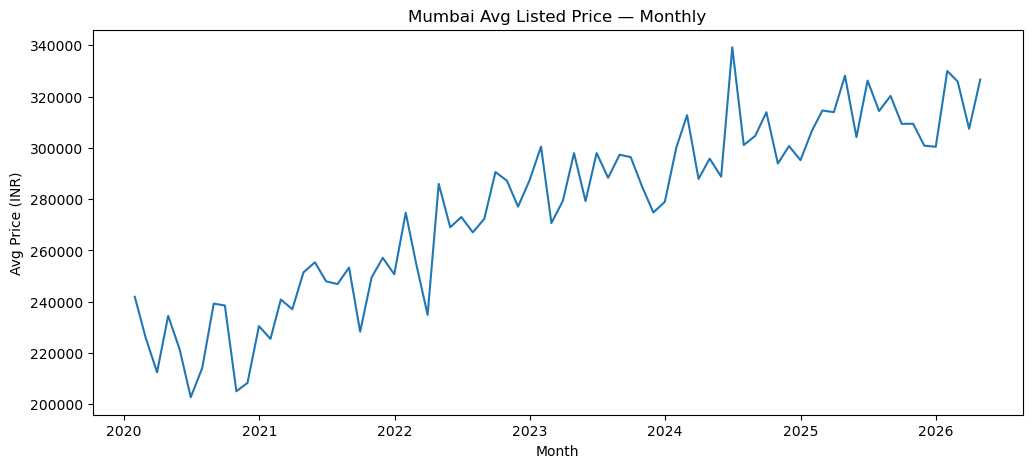

In [185]:
#Aggregate monthly, city-wide
monthly = df.set_index('date_listed').resample('M')['price_usd'].mean().reset_index()
monthly.columns = ['month', 'avg_price']

plt.figure(figsize=(12,5))
plt.plot(monthly['month'], monthly['avg_price'])
plt.title('Mumbai Avg Listed Price — Monthly')
plt.xlabel('Month'); plt.ylabel('Avg Price (INR)')
plt.show()

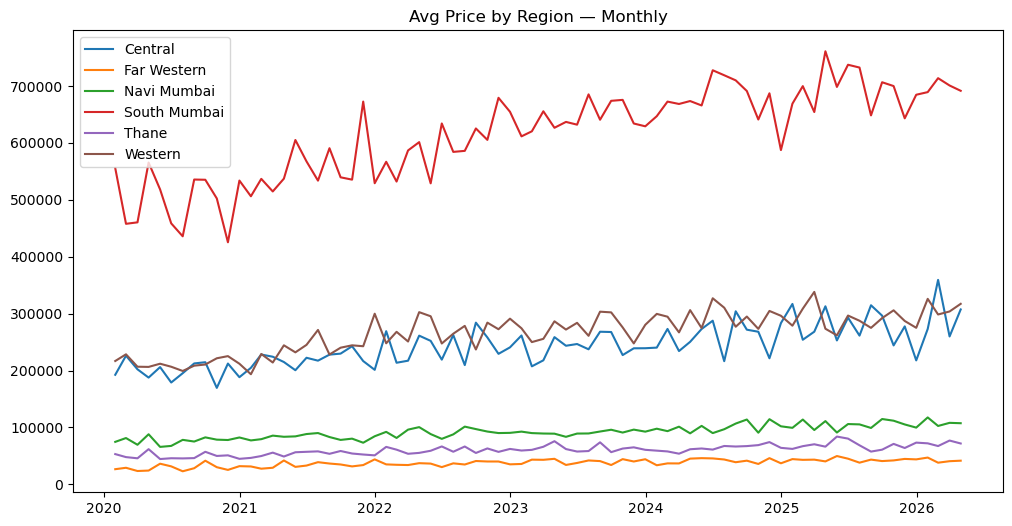

In [186]:
#Aggregate per region — trends likely differ a lot by region
monthly_region = df.set_index('date_listed').groupby('region').resample('M')['price_usd'].mean().reset_index()

plt.figure(figsize=(12,6))
for region in monthly_region['region'].unique():
    sub = monthly_region[monthly_region['region'] == region]
    plt.plot(sub['date_listed'], sub['price_usd'], label=region)
plt.legend()
plt.title('Avg Price by Region — Monthly')
plt.show()

In [187]:
#Chronological train/test split (last 6 months as test)
split_date = monthly['month'].max() - pd.DateOffset(months=6)
train_ts = monthly[monthly['month'] <= split_date].copy()
test_ts = monthly[monthly['month'] > split_date].copy()

In [188]:
#SMA baseline forecast
window = 3
train_ts['sma'] = train_ts['avg_price'].rolling(window=window).mean()


In [189]:
#recursive forecast into the test period
history = list(train_ts['avg_price'])
forecast = []
for _ in range(len(test_ts)):
    next_val = np.mean(history[-window:])
    forecast.append(next_val)
    history.append(next_val)

test_ts['forecast'] = forecast

In [190]:
#Evaluate
mae_ts = mean_absolute_error(test_ts['avg_price'], test_ts['forecast'])
rmse_ts = np.sqrt(mean_squared_error(test_ts['avg_price'], test_ts['forecast']))
mape_ts = np.mean(np.abs((test_ts['avg_price'] - test_ts['forecast']) / test_ts['avg_price'])) * 100
print(f"SMA Forecast — MAE={mae_ts:,.0f}, RMSE={rmse_ts:,.0f}, MAPE={mape_ts:.2f}%")

SMA Forecast — MAE=11,205, RMSE=11,783, MAPE=3.55%


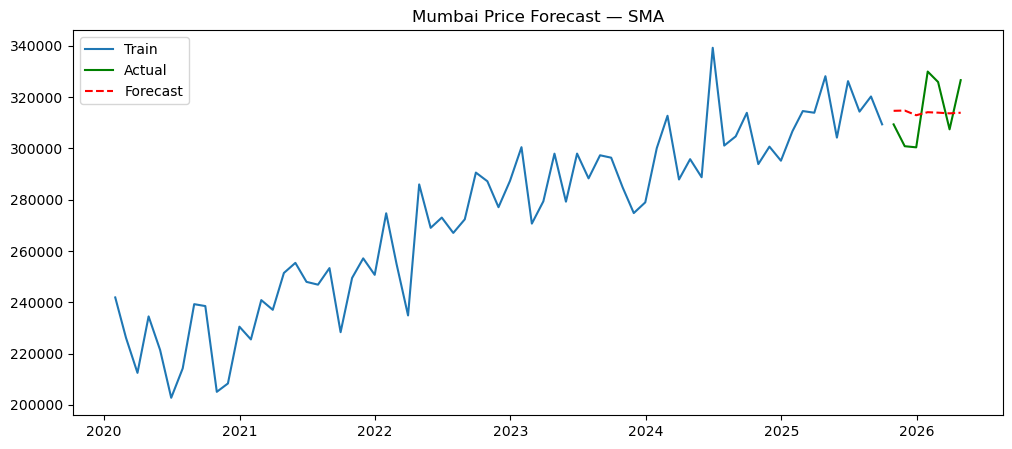

In [191]:
#Plot actual vs forecast
plt.figure(figsize=(12,5))
plt.plot(train_ts['month'], train_ts['avg_price'], label='Train')
plt.plot(test_ts['month'], test_ts['avg_price'], label='Actual', color='green')
plt.plot(test_ts['month'], test_ts['forecast'], label='Forecast', color='red', linestyle='--')
plt.legend()
plt.title('Mumbai Price Forecast — SMA')
plt.show()

# 💡 Recommendations

Based on the analysis of the Mumbai Property Sales dataset, the following recommendations are made:

### 1. Investment
Miss Akoto should focus investments on locations that demonstrate consistent price appreciation and strong market demand. Predictive models can be used to identify emerging investment hotspots before prices increase significantly.

### 2. Home Buyers
Use predictive pricing models to determine whether listed properties are fairly priced before making purchasing decisions.

### 3. Property Developers
Prioritize developments in high-demand areas and incorporate property features that have the greatest influence on selling prices.

### 4. Financial Institutions
Banks and mortgage providers can integrate predictive models into property valuation processes to improve lending decisions and reduce financial risk.

### 5. Future Improvements
Future studies could improve prediction accuracy by incorporating additional variables such as:

- Interest rates
- Inflation
- Population growth
- Crime rates
- School quality
- Distance to business districts
- Public transport accessibility
- Government housing policies